# Error Analysis

This notebook evaluates SquigNet over a range of noise levels and
analyzes failure modes.  We generate a batch of 100 simulated
sequences, add noise sigma from 1.0 to 6.0, compute basecall accuracy
and display a confusion matrix for the four DNA bases.

In [8]:
import sys
from pathlib import Path

# add src path
ROOT = Path('..').resolve()
SRC = str(ROOT / 'src')
if SRC not in sys.path:
    sys.path.insert(0, SRC)

import numpy as np
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

from data_simulator import generate_squiggle, standardize_signal, generate_random_dna_sequence
from inference import run_inference, greedy_decode, load_model
from architecture import SquigNet

## Batch Evaluation
define a helper to simulate with variable noise and run inference.

In [9]:
model = load_model(Path('../models/squig_model.pt'), torch.device('cpu'))

noise_levels = np.linspace(1.0, 6.0, num=10)
results = []
NUM_SAMPLES = 100

for sigma in noise_levels:
    accuracies = []
    all_targets = []
    all_preds = []
    for _ in range(NUM_SAMPLES):
        seq = generate_random_dna_sequence(np.random.randint(50, 101))
        raw, dwell = generate_squiggle(seq)
        sig = standardize_signal(raw)
        # add gaussian noise
        sig = sig + np.random.normal(0, sigma, len(sig))
        logits = run_inference(model, sig)
        pred = greedy_decode(logits)

        # compute per-sequence accuracy: count matches at same indices
        matches = sum(1 for i in range(len(seq)) if i < len(pred) and seq[i] == pred[i])
        acc = matches / len(seq) if len(seq) > 0 else 0.0
        accuracies.append(acc)

        # Ensure equal-length lists for confusion matrix by truncating to
        # the shorter length (avoids mismatched total counts)
        minlen = min(len(seq), len(pred))
        if minlen > 0:
            all_targets.extend(list(seq[:minlen]))
            all_preds.extend(list(pred[:minlen]))

    avg_acc = np.mean(accuracies)
    results.append((sigma, avg_acc, all_targets, all_preds))

## Accuracy vs Noise Level

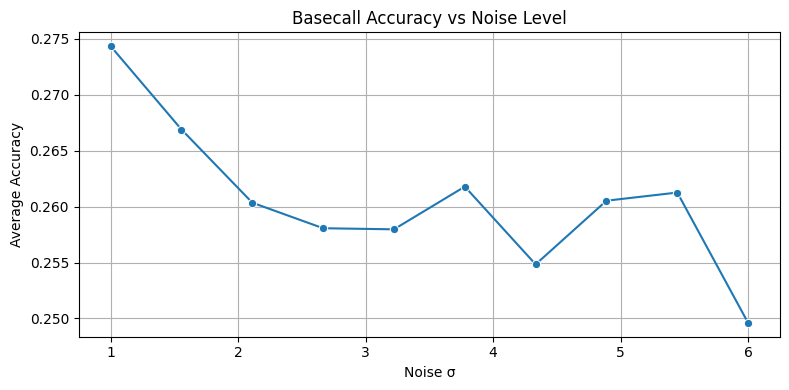

In [11]:
xs = [r[0] for r in results]
ys = [r[1] for r in results]

plt.figure(figsize=(8,4))
sns.lineplot(x=xs, y=ys, marker='o')
plt.title('Basecall Accuracy vs Noise Level')
plt.xlabel('Noise σ')
plt.ylabel('Average Accuracy')
plt.grid(True)
plt.tight_layout()
plt.show()

## Confusion Matrix

Aggregate across all noise levels to see which bases are misclassified
most often.

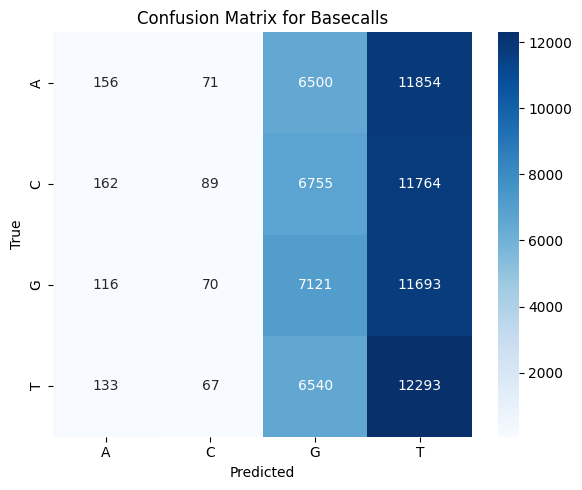

In [12]:
all_t = []
all_p = []
for _,_,t,p in results:
    all_t.extend(t)
    all_p.extend(p)

labels = ['A','C','G','T']
cm = confusion_matrix(all_t, all_p, labels=labels)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=labels, yticklabels=labels, cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix for Basecalls')
plt.tight_layout()
plt.show()

## Future Improvements

- Implement data augmentation (random shifts, scaling, dropout) to
  improve robustness to high noise.
- Explore more complex loss functions (e.g., focal loss, noise-aware
  CTC) to penalize miscalls under noisy conditions.
- Consider ensemble models or calibration layers that adapt to the 
  estimated noise level.
- Perform per-base weighting if some bases suffer disproportionately
  under noise.